In [5]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [6]:
def add_date_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["dow"] = df["date"].dt.dayofweek          # day of week, 0=Monday
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    doy = df["date"].dt.dayofyear                 # day of year (1-365)
    df["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    df["log_distance"] = np.log(df["distance"])
    return df

In [14]:
train = pd.read_csv("train-test.csv")
val = pd.read_csv("validation.csv")

train = add_date_features(train)
val = add_date_features(val)

In [15]:
template = pd.read_csv("validation-predictions.csv")
december_final = pd.read_csv("december-chart-inputs.csv")

In [16]:
NUM_FEATS = ["distance","log_distance","weight","market_index","quote_signal",
             "pickup_lat","pickup_lon","delivery_lat","delivery_lon",
             "month","dow","doy_sin","doy_cos","is_weekend"]
CAT_FEATS = ["equipment"]
FEATS = NUM_FEATS + CAT_FEATS

In [18]:
X = train[FEATS]
y_log = np.log(train["posted_rate"])   # train on the log of the rate

cutoff = train["date"].quantile(0.8)
is_train = train["date"] <= cutoff
is_test = train["date"] > cutoff

In [19]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUM_FEATS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATS),
])
model = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.03, max_depth=5, random_state=42)
pipeline = Pipeline([("prep", preprocessor), ("model", model)])

pipeline.fit(X[is_train], y_log[is_train])
test_pred = np.exp(pipeline.predict(X[is_test]))   # exp() to convert back to dollars
test_actual = train["posted_rate"][is_test]

print("MAE:", mean_absolute_error(test_actual, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(test_actual, test_pred)))
print("MAPE:", mean_absolute_percentage_error(test_actual, test_pred)*100, "%")

MAE: 125.80282359255986
RMSE: 638.6853001506585
MAPE: 5.449353825349598 %


In [23]:
pipeline.fit(X, y_log)   # now using 100% of train_test.csv

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['distance', 'log_distance',
                                                   'weight', 'market_index',
                                                   'quote_signal', 'pickup_lat',
                                                   'pickup_lon', 'delivery_lat',
                                                   'delivery_lon', 'month',
                                                   'dow', 'doy_sin', 'doy_cos',
                                                   'is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['equipment'])])),
                ('model',
                 HistGradientBoostingRegressor(learning_rate=0.03, max_depth=5,
                                               max_iter=600,
                                               random_state=42))])

In [21]:
val_pred = np.exp(pipeline.predict(val[FEATS]))
template["predicted_rate"] = np.round(val_pred, 2)
template.to_csv("validation_predictions.csv", index=False)

In [25]:
# city coordinate lookup table (coordinates are fixed, repeated across train and validation)
coords = pd.concat([
    train[["pickup","pickup_lat","pickup_lon"]].rename(columns={"pickup":"city","pickup_lat":"lat","pickup_lon":"lon"}),
    val[["pickup","pickup_lat","pickup_lon"]].rename(columns={"pickup":"city","pickup_lat":"lat","pickup_lon":"lon"}),
    train[["delivery","delivery_lat","delivery_lon"]].rename(columns={"delivery":"city","delivery_lat":"lat","delivery_lon":"lon"}),
    val[["delivery","delivery_lat","delivery_lon"]].rename(columns={"delivery":"city","delivery_lat":"lat","delivery_lon":"lon"}),
]).drop_duplicates(subset="city").set_index("city")

december = pd.read_csv("december-chart-inputs.csv")
december = add_date_features(december)
december["pickup_lat"] = december["pickup"].map(coords["lat"])
december["pickup_lon"] = december["pickup"].map(coords["lon"])
december["delivery_lat"] = december["delivery"].map(coords["lat"])
december["delivery_lon"] = december["delivery"].map(coords["lon"])

# market_index and quote_signal: use the real December median from validation.csv
december_market = val[val["date"].dt.month==12].groupby(val["date"])[["market_index","quote_signal"]].median()
december["market_index"] = december["date"].map(december_market["market_index"])
december["quote_signal"] = december["date"].map(december_market["quote_signal"])

In [26]:
december_pred = np.exp(pipeline.predict(december[FEATS]))
december_final["predicted_rate"] = np.round(december_pred, 2)
december_final.to_csv("december-chart-inputs.csv", index=False)

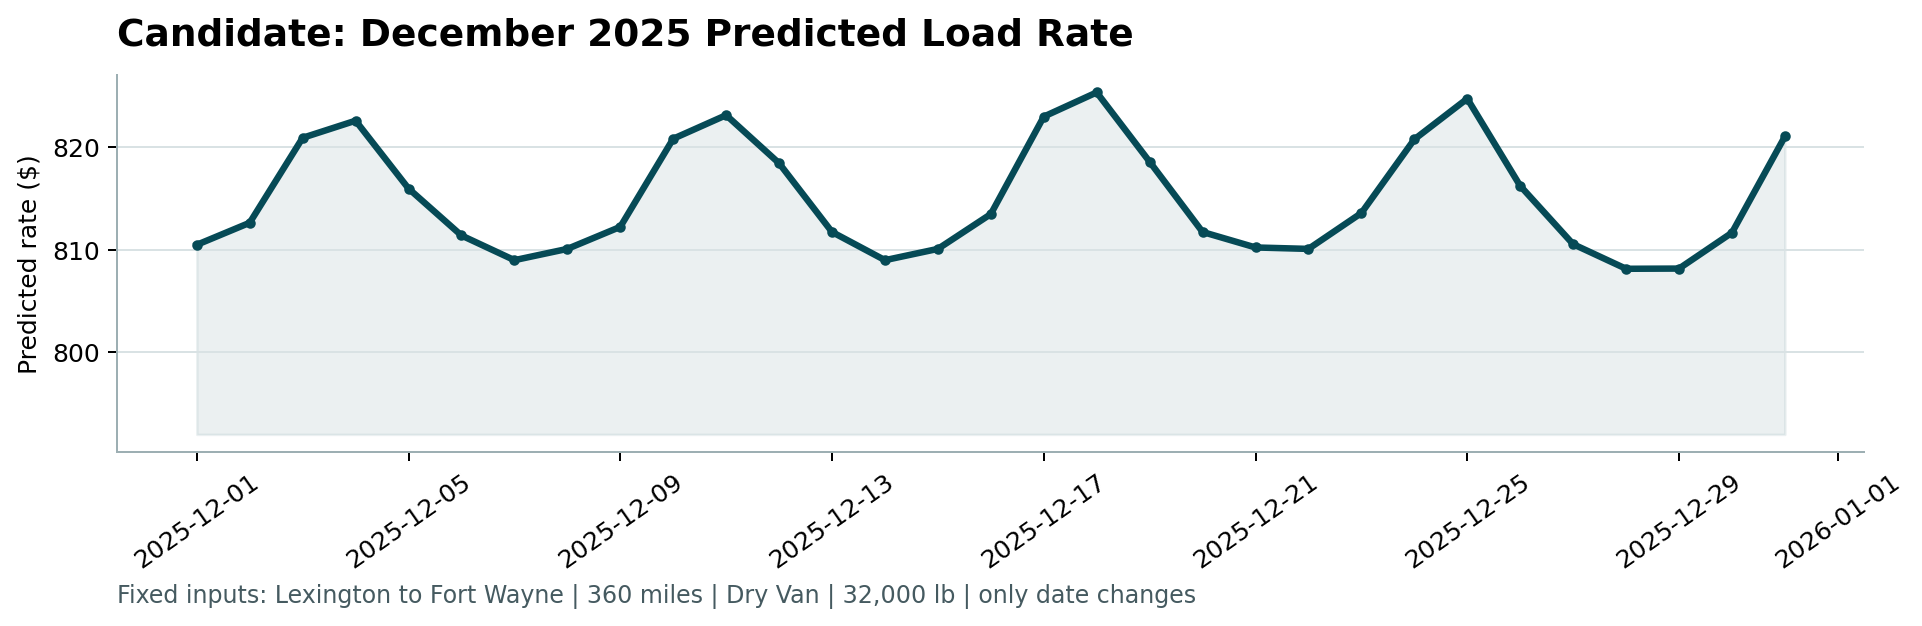

In [29]:
from IPython.display import Image
Image('scorer_results/candidate_december.png')

In [28]:
!python /content/score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv --output-dir scorer_results

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
